# Lesson 3: Pandas for Linear Regression (CSV → NumPy → Model → Plot)

## What you'll learn
- Why we use **pandas** in machine learning workflows
- How to load a **CSV** into a DataFrame
- How to select columns and convert to **NumPy arrays**
- Why we **reshape** `x` for scikit-learn
- How to train a regression model and **plot the line of best fit**
- How multi-feature regression works (two features)

> **Files included with this notebook**
- `study_single.csv` (worked example)
- `movies.csv` (Activity 1)
- `sleep_study.csv` (Activity 2)
- `study_multi.csv` (multi-feature worked example)

Make sure the CSV files are in the **same folder** as this notebook.


## Notes: Why are we using pandas?

We use **pandas** because real datasets usually live in files (especially **CSV**). Pandas lets us:

- Load a CSV quickly: `pd.read_csv(...)`
- Work with data as a table (a **DataFrame**)
- Select columns by name (less error-prone than manual arrays)
- Convert columns into **NumPy arrays** (common in textbooks and useful for ML maths)

In this lesson, our workflow is:

**CSV → pandas DataFrame → select columns → NumPy arrays → reshape X → train model → plot points + line of best fit**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression


## Worked Example (Single Feature): Study time → Exam mark

We will:
1. Load `study_single.csv`
2. Extract `x` and `y` columns
3. Convert to NumPy arrays
4. Reshape `x` for scikit-learn
5. Train Linear Regression
6. Plot points + line of best fit


In [2]:
# 1) Load CSV into a DataFrame (table)
data = pd.read_csv("study_single.csv")

# Quick look at the first rows
data.head()


,Time Spent Studying (hours),Exam Mark (%)
0,1,28
1,2,35
2,3,43
3,4,52
4,5,59


In [3]:
# 2) Select columns and convert to NumPy arrays
# x = feature (input), y = target (output)
x = data["Time Spent Studying (hours)"].to_numpy()
y = data["Exam Mark (%)"].to_numpy()

print("x (first 5):", x[:5])
print("y (first 5):", y[:5])
print("x shape BEFORE reshape:", x.shape)
print("y shape:", y.shape)


x (first 5): [1 2 3 4 5]
y (first 5): [28 35 43 52 59]
x shape BEFORE reshape: (9,)
y shape: (9,)


## Notes: Why do we reshape?

After `.to_numpy()`, `x` is usually **1D** (shape like `(n,)`).

But scikit-learn expects the input features `X` to be **2D**:

- **(rows, features)**

For one feature, that means we need shape **(n, 1)**.

`x.reshape(-1, 1)` means:
- `-1` = “work out how many rows automatically”
- `1` = “make 1 feature column”


In [4]:
# 3) Reshape x into 2D: (n, 1)
X = x.reshape(-1, 1)

print("X shape AFTER reshape:", X.shape)


X shape AFTER reshape: (9, 1)


In [5]:
# 4) Train the model
linear_reg = LinearRegression()
linear_reg.fit(X, y)

# 5) Get line parameters (y = mX + b)
b = linear_reg.intercept_
m = linear_reg.coef_[0]

print("Intercept (b):", b)
print("Slope (m):", m)


Intercept (b): 20.49999999999998
Slope (m): 7.633333333333336


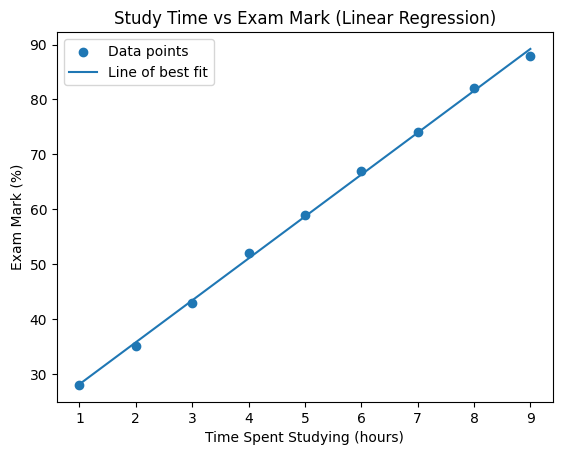

In [6]:
# 6) Predict y values and plot the line of best fit
y_pred = linear_reg.predict(X)

plt.scatter(X, y, label="Data points")
plt.plot(X, y_pred, label="Line of best fit")
plt.xlabel("Time Spent Studying (hours)")
plt.ylabel("Exam Mark (%)")
plt.title("Study Time vs Exam Mark (Linear Regression)")
plt.legend()
plt.show()


---
# Activity 1: Movies (Budget → Box Office)

**File:** `movies.csv`

## Your task
1. Load `movies.csv` using pandas.
2. Convert **Budget ($M)** into `x` and **Box Office ($M)** into `y` using `.to_numpy()`.
3. Print `x.shape` before reshaping.
4. Reshape `x` to 2D with `.reshape(-1, 1)`.
5. Fit a LinearRegression model.
6. Print slope and intercept.
7. Plot the data points and the line of best fit (all in one go).

## Questions (write short answers)
- What does the slope mean in this context?
- Why did we have to reshape `x`?


x shape BEFORE reshape: (9,)
y shape: (9,)
Intercept (b): 30.833333333333314
Slope (m): 2.916666666666667


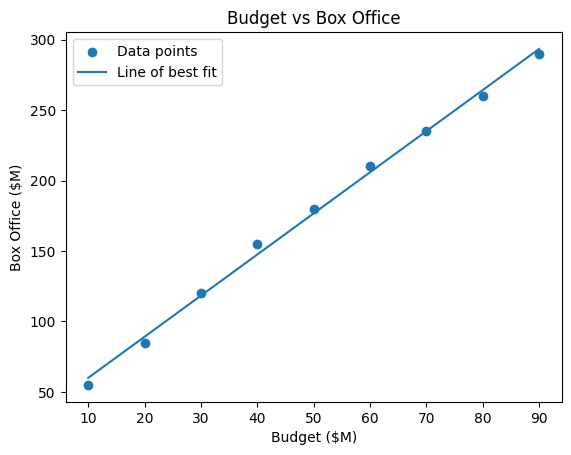

In [7]:
# START HERE (Activity 1)

movies = pd.read_csv("movies.csv")

x = movies["Budget ($M)"].to_numpy()
y = movies["Box Office ($M)"].to_numpy()

print("x shape BEFORE reshape:", x.shape)
print("y shape:", y.shape)

X = x.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

print("Intercept (b):", model.intercept_)
print("Slope (m):", model.coef_[0])

pred = model.predict(X)

plt.scatter(X, y, label="Data points")
plt.plot(X, pred, label="Line of best fit")
plt.xlabel("Budget ($M)")
plt.ylabel("Box Office ($M)")
plt.title("Budget vs Box Office")
plt.legend()
plt.show()


---
# Activity 2: Sleep vs Exam Mark

**File:** `sleep_study.csv`

## Your task
1. Load the CSV.
2. Choose **Sleep (hours)** as `x` and **Exam Mark (%)** as `y`.
3. Convert to NumPy, reshape `x`, train regression, print `m` and `b`, and plot line of best fit.

## Challenge questions
- Do you think a straight line is a good model here? Why/why not?
- Which points look like “noise” (random variation)?


Intercept (b): 21.10714285714286
Slope (m): 5.82142857142857


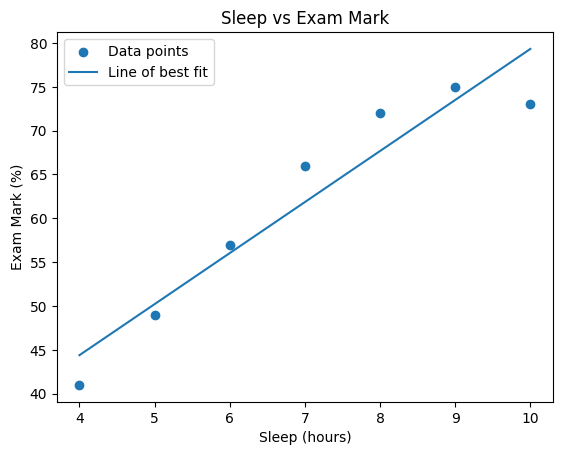

In [8]:
# START HERE (Activity 2)

sleep = pd.read_csv("sleep_study.csv")

x = sleep["Sleep (hours)"].to_numpy()
y = sleep["Exam Mark (%)"].to_numpy()

X = x.reshape(-1, 1)

model = LinearRegression()
model.fit(X, y)

print("Intercept (b):", model.intercept_)
print("Slope (m):", model.coef_[0])

pred = model.predict(X)

plt.scatter(X, y, label="Data points")
plt.plot(X, pred, label="Line of best fit")
plt.xlabel("Sleep (hours)")
plt.ylabel("Exam Mark (%)")
plt.title("Sleep vs Exam Mark")
plt.legend()
plt.show()


---
# Worked Example (Multiple Features): Study time + Assignment mark → Exam mark

**File:** `study_multi.csv`

With **two features**, `X` is already 2D when we select multiple columns, so we **do not** need `reshape(-1, 1)`.

Model idea:

**ExamMark = m1·(StudyTime) + m2·(AssignmentMark) + b**

Each coefficient describes the effect of that feature **while holding the other feature constant**.


In [9]:
multi = pd.read_csv("study_multi.csv")

X = multi[["Time Spent Studying (hours)", "Assignment Mark (%)"]].to_numpy()
y = multi["Exam Mark (%)"].to_numpy()

print("X shape:", X.shape)  # (n, 2)
print("y shape:", y.shape)  # (n,)

model = LinearRegression()
model.fit(X, y)

print("Intercept (b):", model.intercept_)
print("Coefficients [m1, m2]:", model.coef_)

print("\nInterpretation:")
print("m1 = effect of Study Time when Assignment Mark is held constant")
print("m2 = effect of Assignment Mark when Study Time is held constant")


X shape: (7, 2)
y shape: (7,)
Intercept (b): -9.218654314202674
Coefficients [m1, m2]: [6.20860485 0.49081416]

Interpretation:
m1 = effect of Study Time when Assignment Mark is held constant
m2 = effect of Assignment Mark when Study Time is held constant
